# Sprint 2 · Ingeniería de Datos y Pipeline Reproducible
## Predicción de Satisfacción del Cliente — Olist Brazilian E-Commerce
**Grupo 1** · Caso de estudio #1 · *Implementación de Soluciones de IA Aplicada a los Negocios*

---

### Objetivo del Sprint 2
> Construir un **pipeline de datos robusto y escalable**, considerando la incorporación
> mensual de nuevos datos, y definir el **Target Preliminar** del modelo.

### Entregables (según enunciado)
1. **Script modularizado / notebook con pipeline completo** → este notebook + paquete `src/`
2. **Documentación del flujo de datos y versión del pipeline** → `README.md` + `PIPELINE_VERSION`
3. **Métricas técnicas y de negocio finales (versión pipeline)** → sección 9

### Metodología — *flujo de trabajo de Modelos de Negocio* (8 pasos)
| Paso | Etapa | Sprint |
|------|-------|--------|
| 1 | EDA Básico | Sprint 1 ✓ |
| 2 | Población Objetivo / **Target** | **Sprint 2** |
| 3 | Generación de Features | **Sprint 2** |
| 4 | Master Table (split temporal Train/Val/BackTest/Live/Predicción) | **Sprint 2** |
| 5 | Master Table consolidada (features) | **Sprint 2** |
| 6 | Limpieza de variables (clipado, NaN, agrupamiento) | **Sprint 2** |
| 7 | Selección de variables (missing → PSI → correlación → univariante → WOE/IV) | **Sprint 2** |
| 8 | Hiperparametrización (Optuna) y modelo final | Sprint 3 |

> **Target preliminar:** `is_satisfied` (clasificación binaria: `review_score ≥ 4` → satisfecho).
> Se usa clasificación binaria porque las métricas exigidas (F1, ROC-AUC, Gini) y el flujo de
> selección de variables del curso operan sobre **AUC-ROC**.


## 0 · Configuración del entorno

In [1]:
import sys, warnings
sys.path.append("..")            # para encontrar el paquete src/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config as C
from src import utils, features as F, cleaning, selection, pipeline, metrics

# Estilo visual (consistente con el Sprint 1)
PALETTE   = ["#1B4F72", "#2E86C1", "#85C1E9", "#F4D03F", "#E74C3C"]
PALETTE_5 = ["#E74C3C", "#E67E22", "#F4D03F", "#2ECC71", "#1B4F72"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.facecolor": "#F8F9FA", "axes.facecolor": "#FFFFFF",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "axes.titlesize": 13, "axes.labelsize": 11,
})
print("Pipeline version:", C.PIPELINE_VERSION)
print("Target preliminar:", C.TARGET)

Pipeline version: 2.0.0
Target preliminar: is_satisfied


> **Nota sobre los datos.** En producción se colocan los CSV reales de Kaggle en
> `data/raw/`. Para que este notebook sea reproducible sin descargar Kaggle, el repositorio
> incluye `generate_synthetic_data.py`, que crea CSVs sintéticos con el **mismo esquema** y
> relaciones realistas (el retraso reduce la satisfacción). La celda siguiente los genera si
> no existen los reales.

In [2]:
from pathlib import Path
if not (C.RAW_DIR / C.RAW_FILES["orders"]).exists():
    print("No se encontraron CSV en data/raw/ → generando datos de demostración...")
    import generate_synthetic_data as gen
    gen.generate()
else:
    print("CSV encontrados en data/raw/. Usando esos datos.")

CSV encontrados en data/raw/. Usando esos datos.


## 1 · Pasos 4-5 · Construcción de la Master Table
Une las 9 tablas relacionales de Olist en una única tabla a nivel de **pedido** (1 fila = 1 `order_id`).
Las tablas 1-N (`items`, `payments`) se agregan antes de unir. Toda la lógica vive en
`src/utils.py` (`load_raw_csvs`, `build_master_table`, `save_master_table`) — el mismo módulo del Sprint 1.

In [3]:
dfs = utils.load_raw_csvs()
print("Tablas crudas:", {k: v.shape for k, v in dfs.items()})

master = utils.build_master_table(dfs)
utils.save_master_table(master)
master.head(3)

Tablas crudas: {'orders': (40000, 8), 'reviews': (40000, 7), 'items': (49727, 7), 'payments': (40000, 5), 'customers': (40000, 5), 'products': (40000, 9), 'sellers': (40000, 4), 'category': (18, 2)}


Master Table guardada: 40,000 filas x 24 columnas
  -> /home/claude/sprint2/data/processed/master_table.csv


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_comment_message,...,seller_id,product_category_name_english,product_weight_g,product_photos_qty,payment_value,payment_installments,payment_type,customer_state,customer_zip_code_prefix,seller_state
0,3020f96788a168d224d0484aaeae6920,9bac30b7d11675abab5efdb483e6c624,delivered,2017-10-01 03:14:57,2017-10-01 03:20:57.000000000,2017-10-03 15:39:05.773751842,2017-10-23 07:13:40.331789196,2017-11-03 12:46:51.613040972,4,comentario,...,27c76061a84231cf8adfdf8cde55e0a6,stationery,453.0,5,518.12,1,boleto,PR,93995,MG
1,1c9e91d9936abc7ae98d1d15f998625f,ab41be7140da06daae43186197ba87b1,delivered,2018-01-05 19:45:17,2018-01-06 12:23:14.036379886,2018-01-07 04:41:13.157739380,2018-01-14 16:22:24.922082244,2018-01-22 16:29:05.002097731,5,comentario,...,3346b8c94ef0b47104d032bcdda971ed,books_general_interest,185.0,5,124.63,1,boleto,BA,57199,RJ
2,0f3a6710f48bdb7b73e64614d85f071f,012f984fcc62d09fbeb235713434b817,delivered,2018-03-10 04:03:04,2018-03-10 13:37:54.228064062,2018-03-10 20:12:45.095130460,2018-03-16 10:59:19.075919645,2018-03-23 16:21:04.745222731,4,NaN,...,c76f45016ea8baf8df3806a9b87e3495,luggage_accessories,614.0,1,62.17,1,voucher,SP,1540,SP


## 2 · Pasos 2-3 · Población Objetivo, Target y Generación de Features

**Población objetivo:** únicamente pedidos con `order_status == "delivered"` y con `review_score` y
fecha de entrega válidos (`src/features.py::filter_population`).

**Target preliminar:** `is_satisfied = 1` si `review_score ≥ 4`.

**Features generadas** (`src/features.py::engineer_features`) — todas *leak-safe* y calculables mes a mes:
- *Logística:* `delivery_delay_days`, `actual_delivery_days`, `estimated_delivery_days`, `handling_days`, `approval_time_hours`
- *Banderas de entrega:* `delivered_on_time`, `is_late`, `delivered_early_5d`
- *Valor:* `total_price`, `total_freight_value`, `order_total_value`, `freight_ratio`, `price_per_item`, `order_item_count`, `is_multi_item`
- *Pago:* `payment_value`, `payment_installments`, `is_installment`
- *Producto:* `product_weight_g`, `product_photos_qty`, `is_heavy_item`
- *Reseña:* `has_comment`
- *Calendario:* `purchase_dow`, `purchase_month_num`, `purchase_is_weekend`, `same_state_seller`
- *Categóricas:* `product_category_name_english`, `payment_type`, `customer_state`, `seller_state`

In [4]:
df = F.make_features(master)
print(f"Filas tras filtrar población y generar features: {df.shape[0]:,} x {df.shape[1]}")
print(f"Tasa de satisfacción (target=1): {df[C.TARGET].mean()*100:.1f}%")
print(f"Total de features generadas: {len(F.all_feature_columns())}")
df[["order_id", C.MONTH_COL, "delivery_delay_days", "delivered_on_time",
    "has_comment", C.RAW_SCORE_COL, C.TARGET]].head()

Filas tras filtrar población y generar features: 38,800 x 45
Tasa de satisfacción (target=1): 67.1%
Total de features generadas: 30


,order_id,purchase_month,delivery_delay_days,delivered_on_time,has_comment,review_score,is_satisfied
0,3020f96788a168d224d0484aaeae6920,2017-10,-12,1,1,4,1
1,1c9e91d9936abc7ae98d1d15f998625f,2018-01,-9,1,1,5,1
2,0f3a6710f48bdb7b73e64614d85f071f,2018-03,-8,1,0,4,1
3,a31a203dc843e588a9e4879c1b6eb04d,2017-12,-5,1,1,3,0
4,ae71b20f42c39fd599ef1e182a6e13c7,2018-04,-8,1,0,4,1


## 3 · Paso 4 · Split Temporal (incorporación mensual de datos)

El dataset cubre **2016-09 a 2018-09**. Se respeta el orden temporal (nunca se entrena con el futuro),
definiendo cuántos meses entran a *train / val / backtest / live / predicción* — tal como exige el enunciado
(*"identificar cuántos meses entrarán al train, val y backTest"*).

| Partición | Meses | Propósito |
|-----------|-------|-----------|
| **train** | hasta `2018-03` | Entrenamiento |
| **val** | `2018-04` | Validación / ajuste |
| **backtest** | `2018-05`, `06`, `07` | Evaluación *out-of-time* mes a mes |
| **live** | `2018-08` | Último mes con label (simula producción) |
| **predict** | `2018-09` | Mes nuevo sin label → se predice |

La configuración vive en `src/config.py` y se cambia editando un solo archivo.

In [5]:
df = utils.assign_temporal_split(df)
resumen = utils.split_summary(df)
print(resumen.to_string())

train = df[df.dataset_split == "train"].copy()
val   = df[df.dataset_split == "val"].copy()

               filas  mes_min  mes_max
dataset_split                         
train          27613  2016-09  2018-03
val             2406  2018-04  2018-04
backtest        6694  2018-05  2018-07
live            1691  2018-08  2018-08
predict          396  2018-09  2018-09


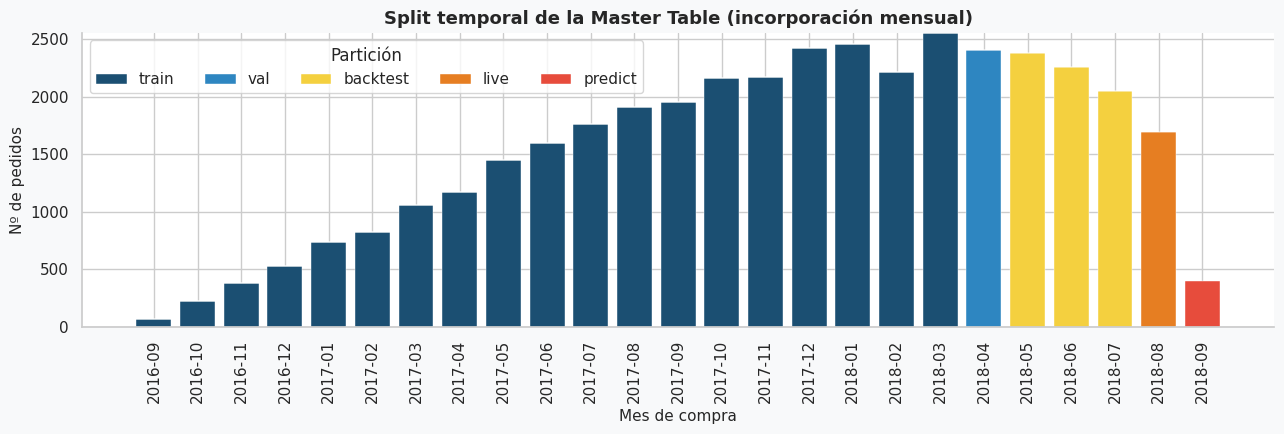

In [6]:
# Visualización del split temporal
monthly = (df.groupby([C.MONTH_COL, "dataset_split"]).size()
           .reset_index(name="n"))
pivot = monthly.pivot(index=C.MONTH_COL, columns="dataset_split", values="n").fillna(0)
order = [c for c in ["train","val","backtest","live","predict"] if c in pivot.columns]
colors = {"train":"#1B4F72","val":"#2E86C1","backtest":"#F4D03F","live":"#E67E22","predict":"#E74C3C"}

fig, ax = plt.subplots(figsize=(13, 4.5))
bottom = np.zeros(len(pivot))
for c in order:
    ax.bar(pivot.index.astype(str), pivot[c], bottom=bottom,
           label=c, color=colors[c], edgecolor="white", linewidth=0.3)
    bottom += pivot[c].values
ax.set_title("Split temporal de la Master Table (incorporación mensual)", fontweight="bold")
ax.set_xlabel("Mes de compra"); ax.set_ylabel("Nº de pedidos")
ax.tick_params(axis="x", rotation=90); ax.legend(title="Partición", ncol=5)
plt.tight_layout(); plt.savefig(C.FIGURES_DIR / "s2_fig01_temporal_split.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Paso 6 · Limpieza de Variables

`src/cleaning.py::DataCleaner` implementa una interfaz **fit/transform**: los parámetros
(cortes de clipado, medianas de imputación, categorías frecuentes) se **aprenden solo del set de TRAIN**
y se aplican idénticos a las demás particiones. Esto **evita fuga de información** y garantiza que el
mismo tratamiento se replique mes a mes.

- **Clipado (winsorización)** de continuas a los percentiles 1-99.
- **Imputación**: numéricas → mediana; binarias → 0; categóricas → `OTHER`.
- **Agrupamiento** de categorías con frecuencia < 1% en la etiqueta `OTHER`.

In [7]:
cleaner = cleaning.DataCleaner().fit(train)
train_c = cleaner.transform(train)
val_c   = cleaner.transform(val)
print("Reporte de limpieza (parámetros aprendidos en TRAIN):\n")
cleaner.report()

Reporte de limpieza (parámetros aprendidos en TRAIN):



,variable,tipo,clip_low,clip_high,fill_value,n_categorias_frecuentes
0,delivery_delay_days,numérica,-19.0,7.0,-6.0,-
1,actual_delivery_days,numérica,3.0,29.0,11.0,-
2,estimated_delivery_days,numérica,3.0,38.0,17.0,-
3,approval_time_hours,numérica,0.124,30.189,5.292,-
4,handling_days,numérica,0.0,8.0,2.0,-
5,order_item_count,numérica,1.0,4.0,1.0,-
6,total_price,numérica,15.147,727.787,118.34,-
7,total_freight_value,numérica,3.35,62.344,17.27,-
8,order_total_value,numérica,29.221,749.676,139.24,-
9,freight_ratio,numérica,0.013,0.624,0.126,-


## 5 · Paso 7 · Selección de Variables (cascada del flujo de trabajo)

`src/selection.py::FeatureSelector` ejecuta la cascada **en el orden exacto del Excel**, evaluando
cada paso con un **Random Forest** y midiendo **AUC-ROC en train y val**:

| Orden | Método | Qué descarta |
|-------|--------|--------------|
| 0 | Estado Inicial | — |
| 1 | `missing_variable_method` | features con > `umbral_missings` de nulos |
| 2 | `PSI_method` | features **inestables en el tiempo** (PSI train↔val > umbral) |
| 3 | `correlation_method` | features **redundantes** entre sí (\|corr\| > umbral) |
| 4 | `univariante_method` | features **sin señal** vs target (Gini univariante < umbral) |
| 5 | `WOE / Information Value` | *ranking* complementario de poder predictivo |

Umbrales (en `config.py`): `umbral_missings=10%`, `bins_PSI=10`, `umbral_correlacion=0.95`, `umbral_univariante=0.05`.

In [8]:
sel = selection.FeatureSelector().fit(train_c, val_c)
print("Cascada de selección (igual que la tabla del flujo de trabajo):\n")
sel.report_table()

Cascada de selección (igual que la tabla del flujo de trabajo):



,orden,metodo,features,auc_roc_train,auc_roc_val
0,0,Estado Inicial,30,0.7296,0.6941
1,1,missing_variable_method,30,0.7296,0.6941
2,2,PSI_method,29,0.7292,0.6930
3,3,correlation_method: 0.95,27,0.7277,0.6932
4,4,univariante_method: 0.05,11,0.7119,0.6862


In [9]:
# Tabla de Information Value (WOE) — poder predictivo univariante
print("Information Value de las features numéricas/binarias:\n")
sel.iv_table()

Information Value de las features numéricas/binarias:



,variable,information_value,fuerza
0,has_comment,0.4016,fuerte
1,delivery_delay_days,0.0665,débil
2,delivered_on_time,0.0466,débil
3,is_late,0.0466,débil
4,actual_delivery_days,0.0332,débil
5,delivered_early_5d,0.0278,débil
6,product_photos_qty,0.0115,sin poder


In [10]:
features = sel.selected_features_
print(f"VARIABLES SELECCIONADAS PARA EL MODELO ({len(features)}):\n")
for f in features:
    print("  •", f)

# Guardar reporte de selección
sel.report_table().to_csv(C.REPORTS_DIR / "feature_selection_report.csv", index=False)
print("\n[Reporte guardado en reports/feature_selection_report.csv]")

VARIABLES SELECCIONADAS PARA EL MODELO (11):

  • delivery_delay_days
  • actual_delivery_days
  • product_photos_qty
  • delivered_on_time
  • is_late
  • delivered_early_5d
  • has_comment
  • product_category_name_english
  • payment_type
  • customer_state
  • seller_state

[Reporte guardado en reports/feature_selection_report.csv]


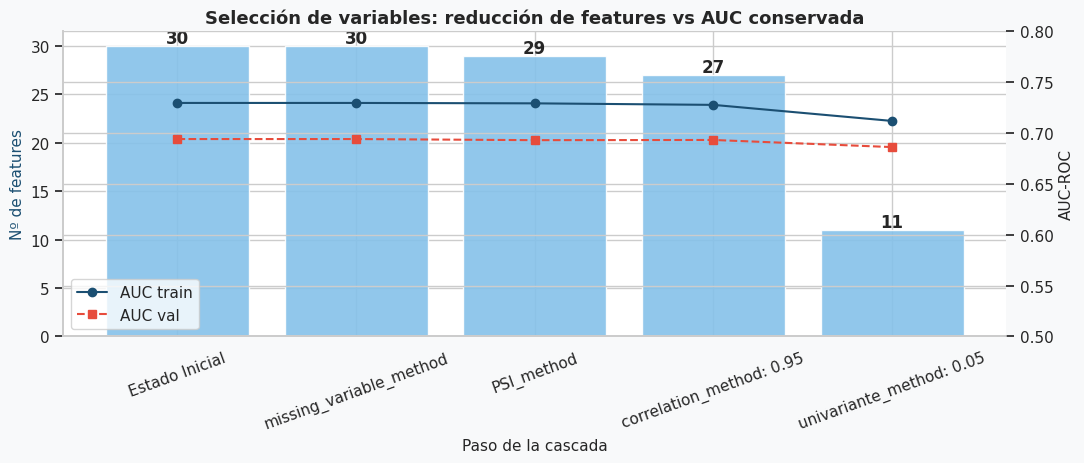

In [11]:
# Visualización de la cascada: features eliminadas vs AUC conservada
rep = sel.report_table()
fig, ax1 = plt.subplots(figsize=(11, 4.8))
ax1.bar(rep["metodo"], rep["features"], color="#85C1E9", edgecolor="white", alpha=0.9)
ax1.set_ylabel("Nº de features", color="#1B4F72"); ax1.set_xlabel("Paso de la cascada")
ax1.tick_params(axis="x", rotation=20)
for i, v in enumerate(rep["features"]):
    ax1.text(i, v + 0.3, str(v), ha="center", fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(rep["metodo"], rep["auc_roc_train"], "o-", color="#1B4F72", label="AUC train")
ax2.plot(rep["metodo"], rep["auc_roc_val"], "s--", color="#E74C3C", label="AUC val")
ax2.set_ylabel("AUC-ROC"); ax2.set_ylim(0.5, 0.8); ax2.legend(loc="lower left")
ax1.set_title("Selección de variables: reducción de features vs AUC conservada",
              fontweight="bold")
plt.tight_layout(); plt.savefig(C.FIGURES_DIR / "s2_fig02_feature_selection.png", dpi=150, bbox_inches="tight")
plt.show()

**Barrido del umbral univariante** (igual que el Excel: `umbral_univariante = [0.1, 0.2, 0.3]`).
Permite escoger el punto óptimo entre nº de variables y AUC en validación.

In [12]:
rows = []
for u in C.UMBRAL_UNIVARIANTE_SWEEP:
    s = selection.FeatureSelector(umbral_univariante=u).fit(train_c, val_c)
    auc_tr, auc_va = selection.evaluate_features(train_c, val_c, s.selected_features_)
    rows.append({"umbral_univariante": u, "n_features": len(s.selected_features_),
                 "auc_train": round(auc_tr, 4), "auc_val": round(auc_va, 4)})
pd.DataFrame(rows)

,umbral_univariante,n_features,auc_train,auc_val
0,0.05,11,0.7119,0.6862
1,0.10,6,0.7031,0.6835
2,0.20,5,0.6880,0.6725
3,0.30,5,0.6880,0.6725


## 6 · Pasos 5-6 · Pipeline Reproducible (scikit-learn)

`src/pipeline.py` ensambla un `Pipeline` de scikit-learn que encapsula **todo** el preprocesamiento
+ el modelo en un único objeto serializable:

```
ColumnTransformer
 ├─ numéricas   → SimpleImputer(mediana) → StandardScaler
 ├─ binarias    → SimpleImputer(moda)
 └─ categóricas → SimpleImputer("OTHER") → OneHotEncoder(handle_unknown="ignore")
        ↓
RandomForestClassifier   (baseline del Sprint 2; se optimiza en Sprint 3)
```

El `handle_unknown="ignore"` del encoder garantiza que **categorías nuevas** que aparezcan en meses
futuros no rompan la predicción — clave para la operación mensual.

In [13]:
pipe = pipeline.build_pipeline(features)
pipe.fit(train_c, train_c[C.TARGET])
print("Pipeline entrenado.")
pipe

Pipeline entrenado.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 7 · Métricas Técnicas y de Negocio Finales (versión pipeline)

Se evalúa el pipeline completo sobre **val**, **backtest** y **live**.
- **Técnicas:** Accuracy, Precision, Recall, F1, ROC-AUC, **Gini** (= 2·AUC−1).
- **Negocio:** Customer Satisfaction Rate, Revenue at Risk, y **% de insatisfechos detectados**
  (utilidad del modelo para intervención temprana).

In [14]:
resultados_tec, resultados_neg = {}, {}
for split_name in ["val", "backtest", "live"]:
    part = df[df.dataset_split == split_name].copy()
    if part.empty:
        continue
    part_c = cleaner.transform(part)
    proba = pipe.predict_proba(part_c[features])[:, 1]
    resultados_tec[split_name] = metrics.technical_metrics(part_c[C.TARGET], proba)
    resultados_neg[split_name] = metrics.business_metrics(part_c, proba)

print("MÉTRICAS TÉCNICAS:")
display(pd.DataFrame(resultados_tec).T)
print("\nMÉTRICAS DE NEGOCIO:")
pd.DataFrame(resultados_neg).T

MÉTRICAS TÉCNICAS:


,accuracy,precision,recall,f1,roc_auc,gini,n,tasa_positivos_real
val,0.6563,0.7787,0.6635,0.7165,0.6872,0.3745,2406.0,0.6546
backtest,0.6612,0.7960,0.6678,0.7263,0.6957,0.3914,6694.0,0.6731
live,0.6629,0.8040,0.6635,0.7270,0.7021,0.4043,1691.0,0.6765



MÉTRICAS DE NEGOCIO:


,customer_satisfaction_rate_pct,unsatisfied_customer_rate_pct,average_review_score,on_time_delivery_rate_pct,average_delay_days_when_late,revenue_at_risk_brl,revenue_at_risk_pct,average_order_value_brl,insatisfechos_detectados,insatisfechos_totales,deteccion_insatisfechos_pct,revenue_en_riesgo_detectado_brl
val,65.46,34.54,3.763,84.04,3.12,147580.22,35.18,174.38,534.0,831.0,64.26,98324.47
backtest,67.31,32.69,3.835,84.45,3.17,370837.29,32.35,171.23,1417.0,2188.0,64.76,238457.65
live,67.65,32.35,3.814,83.26,3.06,99489.67,33.40,176.17,362.0,547.0,66.18,66945.65


In [15]:
# Matriz de confusión sobre backtest
bt = df[df.dataset_split == "backtest"].copy()
bt_c = cleaner.transform(bt)
proba_bt = pipe.predict_proba(bt_c[features])[:, 1]
print("Matriz de confusión (BACKTEST):")
metrics.confusion(bt_c[C.TARGET], proba_bt)

Matriz de confusión (BACKTEST):


,pred: insatisfecho,pred: satisfecho
real: insatisfecho,1417,771
real: satisfecho,1497,3009


## 8 · Simulación de Incorporación Mensual de Datos

Se simula la llegada de datos **mes a mes** (backtest + live): para cada mes se puntúa con el pipeline
ya entrenado y se registran las métricas. Esto valida que el modelo **se mantiene estable en el tiempo**
y prepara el *retraining* mensual automatizado (paso "Aplicar el Pickle" del flujo de trabajo).

In [16]:
monthly_rows = []
for m in C.BACKTEST_MONTHS + [C.LIVE_MONTH]:
    part = df[df[C.MONTH_COL] == m].copy()
    if part.empty:
        continue
    part_c = cleaner.transform(part)
    proba = pipe.predict_proba(part_c[features])[:, 1]
    tm = metrics.technical_metrics(part_c[C.TARGET], proba)
    monthly_rows.append({"mes": m, "n": tm["n"], "roc_auc": tm["roc_auc"],
                         "f1": tm["f1"], "gini": tm["gini"]})
monthly_df = pd.DataFrame(monthly_rows)
monthly_df.to_csv(C.REPORTS_DIR / "monthly_backtest.csv", index=False)
monthly_df

,mes,n,roc_auc,f1,gini
0,2018-05,2381,0.6968,0.7281,0.3937
1,2018-06,2261,0.7076,0.7335,0.4151
2,2018-07,2052,0.6816,0.7163,0.3631
3,2018-08,1691,0.7021,0.7270,0.4043


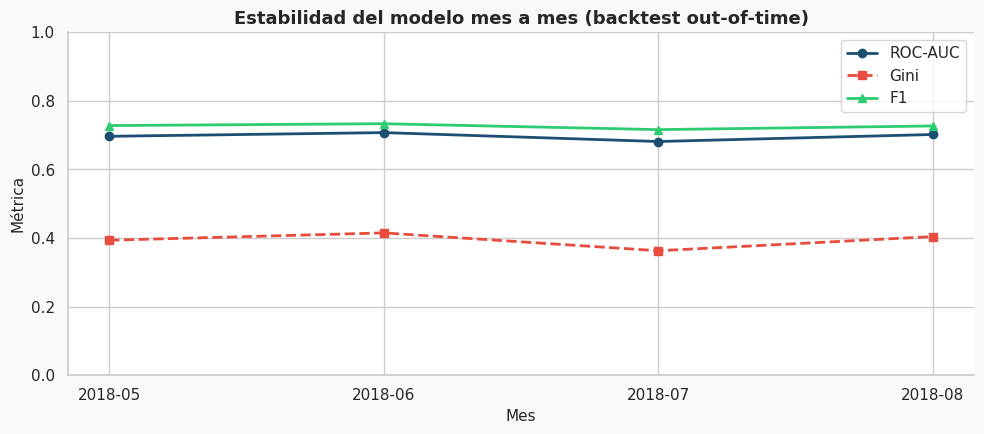

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly_df["mes"], monthly_df["roc_auc"], "o-", color="#1B4F72", lw=2, label="ROC-AUC")
ax.plot(monthly_df["mes"], monthly_df["gini"], "s--", color="#E74C3C", lw=2, label="Gini")
ax.plot(monthly_df["mes"], monthly_df["f1"], "^-", color="#2ECC71", lw=2, label="F1")
ax.set_title("Estabilidad del modelo mes a mes (backtest out-of-time)", fontweight="bold")
ax.set_xlabel("Mes"); ax.set_ylabel("Métrica"); ax.set_ylim(0, 1); ax.legend()
plt.tight_layout(); plt.savefig(C.FIGURES_DIR / "s2_fig03_monthly_stability.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 · Aplicar el Pickle a un Mes Nuevo (predicción sin label)

Se serializa el pipeline + features + metadatos en un **único `.pkl` versionado** y se aplica al mes
de predicción (`2018-09`), que simula datos nuevos **sin label**. Es exactamente el flujo de producción mensual.

In [18]:
meta = utils.run_metadata({"n_features": len(features), "features": features,
                           "stage": "sprint2_baseline"})
art_path = pipeline.save_pipeline(pipe, features, meta)

# Recargar y aplicar a datos nuevos
artifact = pipeline.load_pipeline(art_path)
pred_month = df[df.dataset_split == "predict"].copy()
pred_month_c = cleaner.transform(pred_month)
scored = pipeline.predict_new_data(artifact, pred_month_c)

print(f"Mes de predicción: {C.PREDICTION_MONTH} · {len(scored):,} pedidos puntuados")
print(f"Predichos como satisfechos:  {scored['pred_satisfecho'].mean()*100:.1f}%")
print(f"Pedidos en riesgo (alerta):  {(scored['pred_satisfecho']==0).sum():,}")
scored[["order_id", "delivery_delay_days", "has_comment",
        "proba_satisfecho", "pred_satisfecho"]].head(10)

Pipeline guardado: /home/claude/sprint2/models/satisfaction_pipeline_v2.0.0.pkl
Mes de predicción: 2018-09 · 396 pedidos puntuados
Predichos como satisfechos:  53.8%
Pedidos en riesgo (alerta):  183


,order_id,delivery_delay_days,has_comment,proba_satisfecho,pred_satisfecho
34,bc8659ad995b08119382348952d14fdf,-2,1,0.334281,0
94,4a65cbb0d8214755c187a1e37967ed81,-1,0,0.612281,1
134,d5f30059ad0044b84e7f50f5c12880b9,-19,0,0.700637,1
174,a85602226e06a315761358765d809fd0,-8,1,0.430915,0
374,630453cb4cd7b15ef87cac93db4407dd,1,0,0.595561,1
478,6e3028ab335244201b04809ab983ce32,-12,1,0.393578,0
511,f29a778306ef3dd47813b3a6b36617c4,-11,1,0.467186,0
569,9b3a96c9332f09b78d2a0a87ec82a8ea,-2,0,0.635963,1
585,665ec9f45bde86c436cd2b5fb1cc0f14,-1,0,0.642602,1
714,cab8d63d6cacf4d75af266f8c0850cf3,-10,1,0.446883,0


In [19]:
# Guardar métricas finales del Sprint 2 (versión pipeline)
final_metrics = {**meta, "metrics": {"technical": resultados_tec,
                                      "business": resultados_neg,
                                      "monthly_backtest": monthly_rows}}
utils.write_json(final_metrics, C.REPORTS_DIR / "metrics_sprint2.json")
print("Métricas finales guardadas en reports/metrics_sprint2.json")
print("Versión del pipeline:", C.PIPELINE_VERSION)

Métricas finales guardadas en reports/metrics_sprint2.json
Versión del pipeline: 2.0.0


## 10 · Resumen del Sprint 2 y Target Preliminar

### Lo que se entregó
| Entregable | Estado | Ubicación |
|------------|--------|-----------|
| Pipeline modular y reproducible | ✓ | paquete `src/` + `run_pipeline.py` |
| Notebook con pipeline completo | ✓ | este notebook |
| Documentación del flujo + versión | ✓ | `README.md`, `PIPELINE_VERSION = 2.0.0` |
| Métricas técnicas y de negocio (versión pipeline) | ✓ | `reports/metrics_sprint2.json` |
| Simulación de incorporación mensual | ✓ | sección 8 + `reports/monthly_backtest.csv` |
| Modelo serializado (pickle versionado) | ✓ | `models/` |

### Target Preliminar definido
- **Variable:** `is_satisfied` (binaria) · **Regla:** `review_score ≥ 4` → satisfecho.
- **Tipo de problema:** clasificación binaria (métricas F1, ROC-AUC, Gini).
- **Variables del modelo:** las seleccionadas por la cascada (sección 5).

### Hallazgos clave
- El **retraso en la entrega** (`delivery_delay_days`, `delivered_on_time`, `is_late`) y la
  presencia de **comentario** (`has_comment`) son los predictores más fuertes, confirmando las
  hipótesis del Sprint 1.
- El modelo baseline (Random Forest) es **estable mes a mes** en el backtest out-of-time,
  validando el diseño para operación mensual.

### Siguiente paso (Sprint 3)
Optimizar el estimador con **hiperparametrización (Optuna)**, comparar modelos (XGBoost, etc.),
validación cruzada y **exportar el modelo final** con el **Target Final**.
